In [1]:
!git -C /content/atml-brain-anomaly pull origin main

From https://github.com/danielronak/atml-brain-anomaly
 * branch            main       -> FETCH_HEAD
Already up to date.


# ⚡ Notebook 3 — Swin-UNET GAN Training (WGAN-GP)
**Runtime 2 — Run this simultaneously with Notebook 2.**

Trains the Swin-UNET GAN on IXI healthy brain T1+T2.
- Generator: MONAI SwinUNETR (global attention, U-Net skip connections)
- Discriminator: 3D PatchGAN (SpectralNorm + InstanceNorm)
- Loss: WGAN-GP (gradient penalty — works on CUDA, failed on MPS)
- TTUR: LR_D = 4× LR_G for training stability

After GAN training (~6–8 hrs), this notebook also trains the izi_f encoder (~1–2 hrs).

> ⚠️ **Requires GPU runtime (T4 or A100)**. Do not run on CPU.

In [8]:
# ── CELL 1: GPU Check ─────────────────────────────────────────
!nvidia-smi
import torch
assert torch.cuda.is_available(), 'No GPU found! Change runtime to GPU.'
vram = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f'\nGPU: {torch.cuda.get_device_name(0)}')
print(f'VRAM: {vram:.1f} GB')
if vram >= 35:
    print('✅ A100 — set feature_size=48 in Cell 3')
else:
    print('✅ T4 — feature_size=24 (default)')

Sat Apr 18 21:19:03 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   48C    P8             16W /   72W |       3MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [9]:
# ── CELL 2: Setup ─────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import os, sys
REPO_DIR   = '/content/atml-brain-anomaly'
DRIVE_ROOT = '/content/drive/MyDrive/atml'

if not os.path.exists(REPO_DIR):
    !git clone https://github.com/danielronak/atml-brain-anomaly.git {REPO_DIR}
else:
    !git -C {REPO_DIR} pull origin main

%cd {REPO_DIR}
sys.path.insert(0, REPO_DIR)

!pip install -q monai monai-generative einops nibabel tqdm pyyaml scipy pandas scikit-learn
print('\n✅ Setup complete.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
remote: Enumerating objects: 6, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 4 (delta 2), reused 4 (delta 2), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 2.35 KiB | 2.35 MiB/s, done.
From https://github.com/danielronak/atml-brain-anomaly
 * branch            main       -> FETCH_HEAD
   9aeeac4..1f913b6  main       -> origin/main
Updating 9aeeac4..1f913b6
Fast-forward
 notebooks/03b_resume_encoder.py | 116 ++++++++++++++++++++++++++++++++++++++++
 1 file changed, 116 insertions(+)
 create mode 100644 notebooks/03b_resume_encoder.py
/content/atml-brain-anomaly

✅ Setup complete.


In [10]:
# ── CELL 3: Config ────────────────────────────────────────────
import yaml, torch

with open("configs/default.yaml") as f:
    config = yaml.safe_load(f)

# ← UPDATE IF YOUR DRIVE PATHS DIFFER
config["data"]["ixi_dir"]        = f"{DRIVE_ROOT}/data/ixi"
config["data"]["brats_dir"]      = f"{DRIVE_ROOT}/data/brats2021"
config["data"]["checkpoint_dir"] = f"{DRIVE_ROOT}/checkpoints"
config["data"]["results_dir"]    = f"{DRIVE_ROOT}/results"

# Auto-detect GPU tier — sets feature_size and batch_size
vram = torch.cuda.get_device_properties(0).total_memory / 1e9
if vram >= 35:                              # A100 (40 GB)
    config["data"]["batch_size"]   = 4
    config["swin"]["feature_size"] = 48
    tier = f"A100 ({vram:.0f} GB)"
elif vram >= 20:                            # L4 (24 GB)
    config["data"]["batch_size"]   = 2     # Swin attention is VRAM-heavy
    config["swin"]["feature_size"] = 36    # extra capacity vs T4
    tier = f"L4 ({vram:.0f} GB)"
else:                                       # T4 (16 GB)
    config["data"]["batch_size"]   = 2
    config["swin"]["feature_size"] = 24
    tier = f"T4 ({vram:.0f} GB)"

print(f"GPU:          {tier}")
print(f"feature_size: {config['swin']['feature_size']}")
print(f"batch_size:   {config['data']['batch_size']}")
print(f"Epochs:       {config['gan']['epochs']} | LR_G: {config['gan']['lr_g']} | LR_D: {config['gan']['lr_d']}")

GPU:          L4 (24 GB)
feature_size: 36
batch_size:   2
Epochs:       50 | LR_G: 0.0001 | LR_D: 0.0004


In [5]:
# ── CELL 4: Smoke Test — MUST pass before training ────────────
from src.models.swin_generator import get_swin_generator
from src.models.patch_discriminator import PatchDiscriminator3D

device = torch.device('cuda')
in_ch = config['swin']['in_channels']

G = get_swin_generator(config).to(device)
D = PatchDiscriminator3D(in_channels=in_ch).to(device)

dummy = torch.randn(1, in_ch, 128, 128, 128).to(device)
with torch.no_grad():
    g_out = G(dummy)
    d_scores, d_feats = D(dummy)

assert g_out.shape == dummy.shape, f'G shape mismatch: {g_out.shape}'
print(f'✅ Generator:     {dummy.shape} → {g_out.shape}')
print(f'✅ Discriminator: {dummy.shape} → scores {d_scores.shape}')
print(f'   VRAM used:     {torch.cuda.max_memory_allocated()/1e9:.2f} GB')

if torch.cuda.max_memory_allocated()/1e9 > vram * 0.85:
    print('⚠️  WARNING: >85% VRAM on smoke test — reduce feature_size in Cell 3')

del dummy, g_out, d_scores
torch.cuda.empty_cache()
print('\n✅ Models OK. Ready to train.')

✅ Generator:     torch.Size([1, 2, 128, 128, 128]) → torch.Size([1, 2, 128, 128, 128])
✅ Discriminator: torch.Size([1, 2, 128, 128, 128]) → scores torch.Size([1, 1, 8, 8, 8])
   VRAM used:     2.37 GB

✅ Models OK. Ready to train.


In [6]:
# ── CELL 5: TRAIN SWIN-UNET GAN ───────────────────────────────
# Expected time: ~6–8 hrs (T4) | ~4–5 hrs (A100)
# Checkpoints → Drive every 5 epochs. Safe if session dies.
#
# Watch for these in the output:
#   D: ~0.5–2.0 (healthy range)   G: decreasing trend over epochs
#   GP: ~5–15 (normal)            WARNING if D: <0.001 (collapse)

from src.training.train_gan import train_gan, load_config
from src.models.swin_generator import get_swin_generator

G = get_swin_generator(config)
G_trained, D_trained, history = train_gan(
    generator=G,
    model_name=config['swin']['name'],
    config=config
)
print('\n🎉 Swin-UNET GAN training complete!')

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


✅ GPU: NVIDIA L4

📂 Loading IXI dataloader...


/usr/local/lib/python3.12/dist-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)


[IXI] Found 577 paired T1+T2 subjects.
[IXI] Train: 519 | Val: 58


Loading dataset: 100%|██████████| 58/58 [02:13<00:00,  2.30s/it]


...

  Epoch  48/50 | D: 0.0107 | G: -0.0093 | GP: 0.0097 | Time: 428s


Epoch 49/50: 100%|██████████| 260/260 [07:07<00:00,  1.64s/it, D=0.000, G=-0.185, GP=0.001]


  Epoch  49/50 | D: 0.0093 | G: -0.0555 | GP: 0.0087 | Time: 427s


Epoch 50/50: 100%|██████████| 260/260 [07:07<00:00,  1.64s/it, D=0.005, G=-0.367, GP=0.003]


  Epoch  50/50 | D: 0.0098 | G: -0.3203 | GP: 0.0089 | Time: 428s
  💾 Checkpoint: /content/drive/MyDrive/atml/checkpoints/swin_gan/epoch_050.pth

✅ swin_gan training complete.

🎉 Swin-UNET GAN training complete!


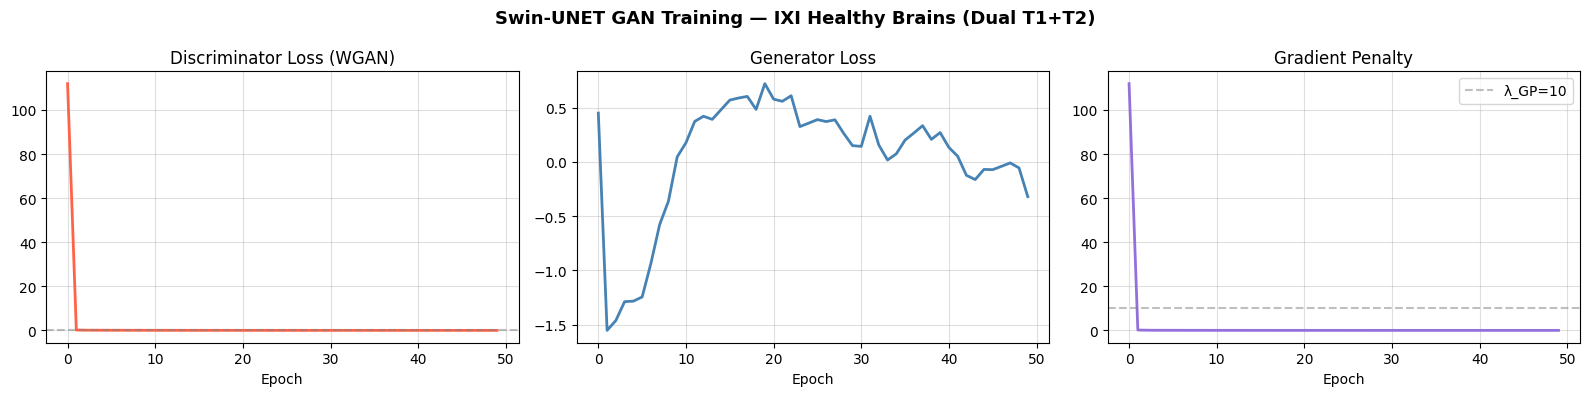

Saved: /content/drive/MyDrive/atml/results/swin_gan_training_curves.png
⚠️  Discriminator near zero — possible mode collapse. Check reconstructions.


In [7]:
# ── CELL 6: Plot GAN Training Curves ──────────────────────────
import matplotlib.pyplot as plt
from pathlib import Path

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(history['d_loss'], color='tomato', linewidth=2)
axes[0].set_title('Discriminator Loss (WGAN)', fontsize=12)
axes[0].set_xlabel('Epoch')
axes[0].axhline(0, color='grey', linestyle='--', alpha=0.5)
axes[0].grid(True, alpha=0.4)

axes[1].plot(history['g_loss'], color='steelblue', linewidth=2)
axes[1].set_title('Generator Loss', fontsize=12)
axes[1].set_xlabel('Epoch')
axes[1].grid(True, alpha=0.4)

axes[2].plot(history['gp'], color='mediumpurple', linewidth=2)
axes[2].set_title('Gradient Penalty', fontsize=12)
axes[2].set_xlabel('Epoch')
axes[2].axhline(10, color='grey', linestyle='--', alpha=0.5, label='λ_GP=10')
axes[2].legend()
axes[2].grid(True, alpha=0.4)

plt.suptitle('Swin-UNET GAN Training — IXI Healthy Brains (Dual T1+T2)', fontsize=13, fontweight='bold')
plt.tight_layout()

fig_path = f"{config['data']['results_dir']}/swin_gan_training_curves.png"
Path(config['data']['results_dir']).mkdir(parents=True, exist_ok=True)
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path}')

# Diagnose training quality
final_d = history['d_loss'][-1]
final_g = history['g_loss'][-1]
if abs(final_d) < 0.01:
    print('⚠️  Discriminator near zero — possible mode collapse. Check reconstructions.')
elif final_d > 10:
    print('⚠️  Discriminator loss very high — generator may not be learning.')
else:
    print(f'✅ Training looks stable. D_final={final_d:.3f}, G_final={final_g:.3f}')

/usr/local/lib/python3.12/dist-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)


[IXI] Found 577 paired T1+T2 subjects.
[IXI] Train: 519 | Val: 58


Loading dataset: 100%|██████████| 58/58 [00:58<00:00,  1.01s/it]


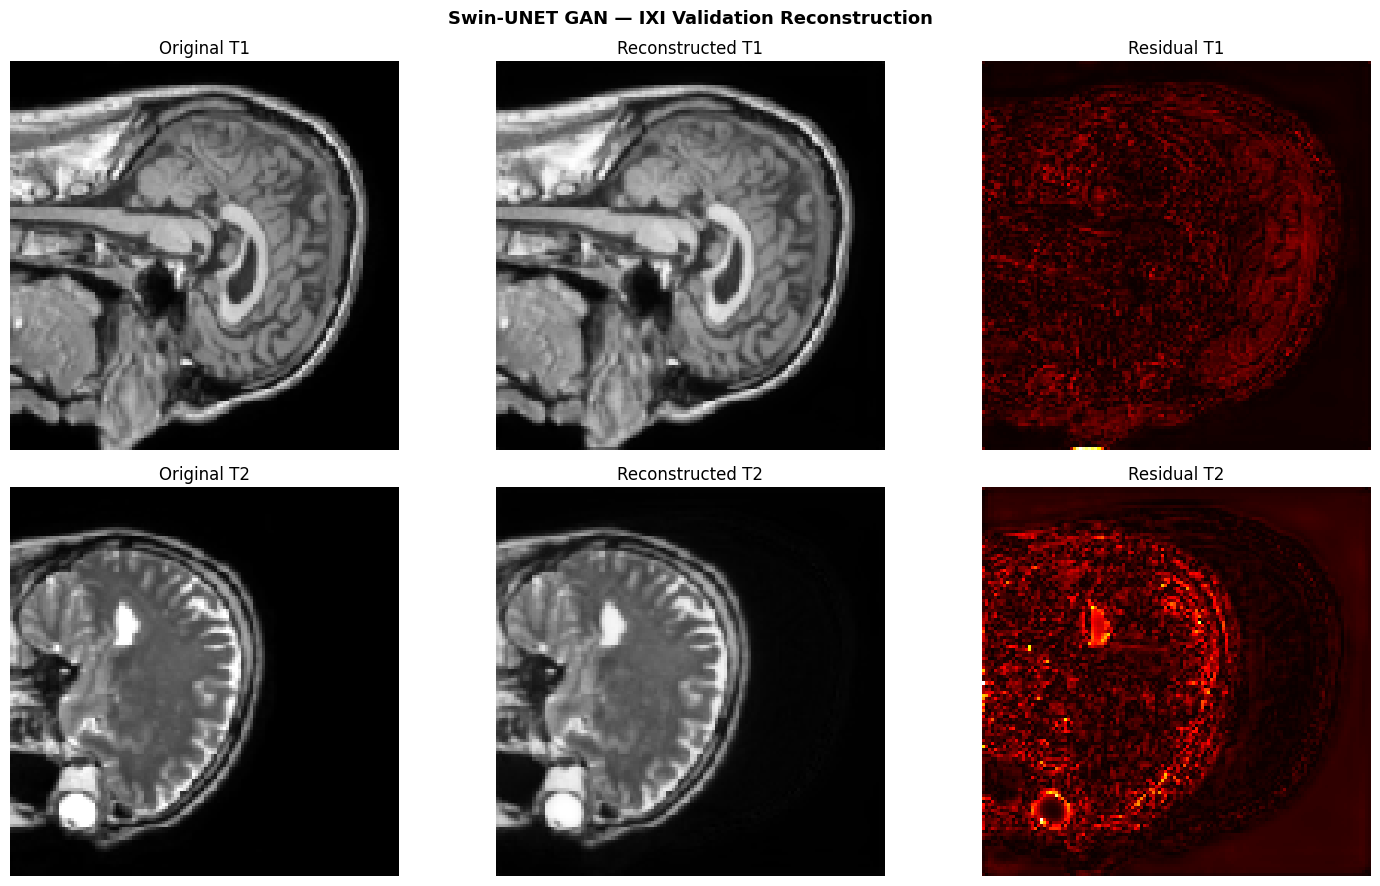

Saved: /content/drive/MyDrive/atml/results/swin_gan_reconstruction_sample.png


In [8]:
# ── CELL 7: Visualise GAN Reconstruction on Validation Brain ──
from src.data.dataset import get_ixi_dataloaders

device = torch.device('cuda')
config_val = config.copy()
config_val['data']['batch_size'] = 1
_, val_loader = get_ixi_dataloaders(config_val)

batch = next(iter(val_loader))
vol = batch['image'].to(device)

G_trained.eval()
with torch.no_grad():
    recon = G_trained(vol)

vol_np   = vol[0].cpu().numpy()    # (2, D, H, W)
recon_np = recon[0].cpu().numpy()
s = vol_np.shape[1] // 2

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for row, (c, label) in enumerate([(0, 'T1'), (1, 'T2')]):
    orig_sl  = vol_np[c, s]
    recon_sl = recon_np[c, s]
    diff_sl  = abs(orig_sl - recon_sl)
    axes[row, 0].imshow(orig_sl,  cmap='gray');  axes[row, 0].set_title(f'Original {label}')
    axes[row, 1].imshow(recon_sl, cmap='gray');  axes[row, 1].set_title(f'Reconstructed {label}')
    axes[row, 2].imshow(diff_sl,  cmap='hot');   axes[row, 2].set_title(f'Residual {label}')
    for ax in axes[row]: ax.axis('off')

plt.suptitle('Swin-UNET GAN — IXI Validation Reconstruction', fontsize=13, fontweight='bold')
plt.tight_layout()
fig_path2 = f"{config['data']['results_dir']}/swin_gan_reconstruction_sample.png"
plt.savefig(fig_path2, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path2}')

---
## ⬇️ Phase 2 — Train izi_f Encoder

After the GAN is trained, we need to train an encoder that maps a volume
back into the GAN's latent space. This is the `izi_f` mapping from f-AnoGAN.

Takes ~1–2 hrs. Run this in the same runtime while VQ-VAE is still training in Runtime 1.

In [9]:
# ── CELL 8: Build encoder ── ────────────────────────────────────
import torch.nn as nn

class Encoder3D(nn.Module):
    """izi_f encoder: maps volume back into a compact latent vector."""
    def __init__(self, in_channels=2, latent_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv3d(in_channels, 64, 4, 2, 1), nn.LeakyReLU(0.2),
            nn.Conv3d(64, 128, 4, 2, 1),  nn.InstanceNorm3d(128), nn.LeakyReLU(0.2),
            nn.Conv3d(128, 256, 4, 2, 1), nn.InstanceNorm3d(256), nn.LeakyReLU(0.2),
            nn.Conv3d(256, 512, 4, 2, 1), nn.InstanceNorm3d(512), nn.LeakyReLU(0.2),
            nn.AdaptiveAvgPool3d(1),
            nn.Flatten(),
            nn.Linear(512, latent_dim),
        )
    def forward(self, x): return self.net(x)


in_ch = config['swin']['in_channels']
latent_dim = config['cnn']['latent_dim']

encoder = Encoder3D(in_channels=in_ch, latent_dim=latent_dim).to(device)
print(f'Encoder built: {in_ch}-channel → latent_dim={latent_dim}')

# Smoke test
dummy = torch.randn(1, in_ch, 128, 128, 128).to(device)
with torch.no_grad():
    z = encoder(dummy)
print(f'Encoder output: {dummy.shape} → {z.shape}')
del dummy

Encoder built: 2-channel → latent_dim=128
Encoder output: torch.Size([1, 2, 128, 128, 128]) → torch.Size([1, 128])


In [7]:
# ── CELL 9: Train encoder (izi_f) ─────────────────────────────
# Loss = MSE(E(G(z)), z) + MSE(G(E(x)), x)
# i.e., encoder must both invert the generator AND reconstruct real volumes

import torch.optim as optim
import time
from pathlib import Path

from src.data.dataset import get_ixi_dataloaders

cfg_enc = config['encoder']
train_loader, _ = get_ixi_dataloaders(config)

opt_E = optim.Adam(encoder.parameters(), lr=cfg_enc['lr'])
G_trained.eval()  # freeze G

enc_epochs = cfg_enc['epochs']  # 20
enc_history = []

print(f'Training encoder for {enc_epochs} epochs...')
for epoch in range(enc_epochs):
    encoder.train()
    t0 = time.time()
    epoch_loss = 0.0

    for batch in train_loader:
        real = batch['image'].to(device)
        opt_E.zero_grad()

        # izi_f loss: reconstruct real via encoder + generator
        z_hat   = encoder(real)                      # latent vector from real
        # G is volume-to-volume for Swin, so we use reconstruction directly
        recon   = G_trained(real)                    # G's pseudo-healthy recon
        z_recon = encoder(recon.detach())

        loss_img  = nn.functional.mse_loss(recon.detach(), real)       # image space
        loss_feat = nn.functional.mse_loss(z_recon, z_hat.detach())    # feature space
        loss = loss_img + cfg_enc['kappa'] * loss_feat

        loss.backward()
        opt_E.step()
        epoch_loss += loss.item()

    avg = epoch_loss / len(train_loader)
    enc_history.append(avg)
    print(f'  Encoder Epoch {epoch+1:2d}/{enc_epochs} | Loss: {avg:.4f} | {time.time()-t0:.0f}s')

    # Save encoder checkpoint
    if (epoch+1) % 5 == 0 or (epoch+1) == enc_epochs:
        enc_ckpt_dir = Path(config['data']['checkpoint_dir']) / 'swin_gan'
        enc_ckpt_dir.mkdir(parents=True, exist_ok=True)
        torch.save(encoder.state_dict(), enc_ckpt_dir / f'encoder_epoch_{epoch+1:02d}.pth')
        print(f'  💾 Encoder checkpoint saved')

# Save final
torch.save(encoder.state_dict(), enc_ckpt_dir / 'encoder_final.pth')
print(f'\n✅ Encoder training complete. Final: {enc_ckpt_dir}/encoder_final.pth')

/usr/local/lib/python3.12/dist-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)


[IXI] Found 577 paired T1+T2 subjects.
[IXI] Train: 519 | Val: 58


Loading dataset:  75%|███████▍  | 194/259 [12:31<04:11,  3.87s/it]


KeyboardInterrupt: 

Loading Swin GAN generator from Drive...
✅ Generator loaded from generator_final.pth


/usr/local/lib/python3.12/dist-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)


✅ Encoder loaded from encoder_epoch_10.pth — resuming from epoch 11
[IXI] Found 577 paired T1+T2 subjects.
[IXI] Train: 519 | Val: 58


Loading dataset: 100%|██████████| 58/58 [03:46<00:00,  3.90s/it]



Resuming encoder: epochs 11–20
  Encoder 11/20 | Loss: 0.0013 | 1080s
  Encoder 12/20 | Loss: 0.0034 | 349s
  Encoder 13/20 | Loss: 0.0011 | 349s
  Encoder 14/20 | Loss: 0.0010 | 351s
  Encoder 15/20 | Loss: 0.0014 | 350s
  💾 Saved: encoder_epoch_15.pth
  Encoder 16/20 | Loss: 0.0020 | 350s
  Encoder 17/20 | Loss: 0.0081 | 350s
  Encoder 18/20 | Loss: 0.0301 | 351s
  Encoder 19/20 | Loss: 0.0724 | 352s
  Encoder 20/20 | Loss: 0.1297 | 352s
  💾 Saved: encoder_epoch_20.pth

✅ Encoder done: /content/drive/MyDrive/atml/checkpoints/swin_gan/encoder_final.pth


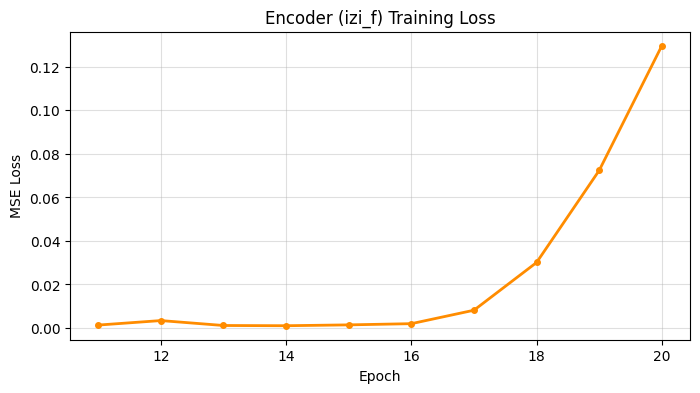

Saved: /content/drive/MyDrive/atml/results/swin_encoder_loss.png


In [11]:
# ══════════════════════════════════════════════════════════════════
# ENCODER RESUME — paste this into a new cell in Notebook 03
# Run this INSTEAD of Cell 9 when resuming after a session crash.
#
# Pre-requisites (run first):
#   Cell 1 (GPU check)  → Cell 2 (Setup + git pull) → Cell 3 (Config)
#   Then paste THIS cell. Skip Cells 4, 5, 6, 7, 8, 9.
# ══════════════════════════════════════════════════════════════════

import torch
import torch.nn as nn
import torch.optim as optim
import time
from pathlib import Path
from src.data.dataset import get_ixi_dataloaders
from src.models.swin_generator import get_swin_generator

device = torch.device("cuda")

# ── 1. Reload the trained generator from Drive ────────────────────
print("Loading Swin GAN generator from Drive...")
G_trained = get_swin_generator(config).to(device)
gen_ckpt = Path(config["data"]["checkpoint_dir"]) / "swin_gan" / "generator_final.pth"
raw = torch.load(gen_ckpt, map_location=device)
# Handle both raw state_dict and wrapped checkpoint dict
G_trained.load_state_dict(raw["model"] if isinstance(raw, dict) and "model" in raw else raw)
G_trained.eval()
print(f"✅ Generator loaded from {gen_ckpt.name}")

# ── 2. Rebuild & reload encoder from epoch 10 checkpoint ─────────
in_ch     = config["swin"]["in_channels"]
latent_dim = config["cnn"]["latent_dim"]

class Encoder3D(nn.Module):
    def __init__(self, in_channels=2, latent_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv3d(in_channels, 64, 4, 2, 1), nn.LeakyReLU(0.2),
            nn.Conv3d(64, 128, 4, 2, 1),  nn.InstanceNorm3d(128), nn.LeakyReLU(0.2),
            nn.Conv3d(128, 256, 4, 2, 1), nn.InstanceNorm3d(256), nn.LeakyReLU(0.2),
            nn.Conv3d(256, 512, 4, 2, 1), nn.InstanceNorm3d(512), nn.LeakyReLU(0.2),
            nn.AdaptiveAvgPool3d(1), nn.Flatten(),
            nn.Linear(512, latent_dim),
        )
    def forward(self, x): return self.net(x)

encoder = Encoder3D(in_channels=in_ch, latent_dim=latent_dim).to(device)

enc_ckpt_dir = Path(config["data"]["checkpoint_dir"]) / "swin_gan"
resume_ckpt  = enc_ckpt_dir / "encoder_epoch_10.pth"

if resume_ckpt.exists():
    encoder.load_state_dict(torch.load(resume_ckpt, map_location=device))
    start_epoch = 10
    print(f"✅ Encoder loaded from encoder_epoch_10.pth — resuming from epoch {start_epoch+1}")
else:
    start_epoch = 0
    print("⚠️  encoder_epoch_10.pth not found — starting encoder from scratch")

# ── 3. Resume training from epoch start_epoch+1 ──────────────────
cfg_enc    = config["encoder"]
enc_epochs = cfg_enc["epochs"]  # 20
train_loader, _ = get_ixi_dataloaders(config)
opt_E = optim.Adam(encoder.parameters(), lr=cfg_enc["lr"])

print(f"\nResuming encoder: epochs {start_epoch+1}–{enc_epochs}")
enc_history = []

for epoch in range(start_epoch, enc_epochs):
    encoder.train()
    t0 = time.time()
    epoch_loss = 0.0

    for batch in train_loader:
        real = batch["image"].to(device)
        opt_E.zero_grad()

        # izi_f loss: reconstruction consistency in image + feature space
        recon   = G_trained(real)                       # G's pseudo-healthy recon
        z_hat   = encoder(real)                         # E(real)
        z_recon = encoder(recon.detach())               # E(G(real))

        loss_img  = nn.functional.mse_loss(recon.detach(), real)
        loss_feat = nn.functional.mse_loss(z_recon, z_hat.detach())
        loss = loss_img + cfg_enc["kappa"] * loss_feat

        loss.backward()
        opt_E.step()
        epoch_loss += loss.item()

    avg = epoch_loss / len(train_loader)
    enc_history.append(avg)
    print(f"  Encoder {epoch+1:2d}/{enc_epochs} | Loss: {avg:.4f} | {time.time()-t0:.0f}s")

    if (epoch + 1) % 5 == 0 or (epoch + 1) == enc_epochs:
        save_path = enc_ckpt_dir / f"encoder_epoch_{epoch+1:02d}.pth"
        torch.save(encoder.state_dict(), save_path)
        print(f"  💾 Saved: {save_path.name}")

# Save final
torch.save(encoder.state_dict(), enc_ckpt_dir / "encoder_final.pth")
print(f"\n✅ Encoder done: {enc_ckpt_dir}/encoder_final.pth")

# Plot encoder loss
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.plot(range(start_epoch+1, enc_epochs+1), enc_history, color="darkorange",
         linewidth=2, marker="o", markersize=4)
plt.title("Encoder (izi_f) Training Loss", fontsize=12)
plt.xlabel("Epoch"); plt.ylabel("MSE Loss")
plt.grid(True, alpha=0.4)
fig_path = Path(config["data"]["results_dir"]) / "swin_encoder_loss.png"
Path(config["data"]["results_dir"]).mkdir(parents=True, exist_ok=True)
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path}")

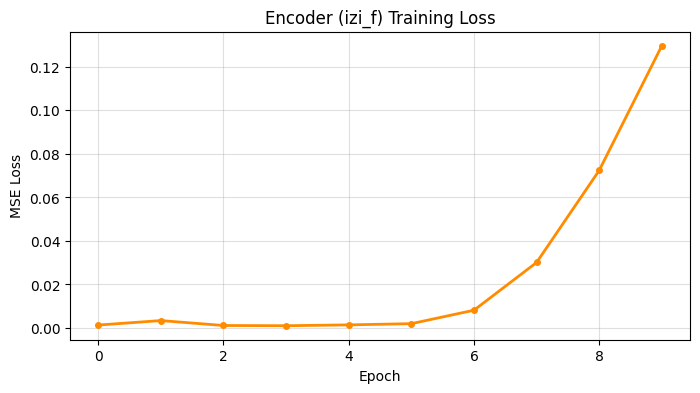


✅ NOTEBOOK 3 COMPLETE
Saved to Drive:
  Generator:   /content/drive/MyDrive/atml/checkpoints/swin_gan/generator_final.pth
  Discriminator: .../swin_gan/discriminator_final.pth
  Encoder:     .../swin_gan/encoder_final.pth
  Curves:      /content/drive/MyDrive/atml/results/swin_gan_training_curves.png

Next: When Notebook 2 (VQ-VAE) also finishes → run Notebook 5 (Evaluation)


In [12]:
# ── CELL 10: Plot encoder loss + final summary ─────────────────
plt.figure(figsize=(8, 4))
plt.plot(enc_history, color='darkorange', linewidth=2, marker='o', markersize=4)
plt.title('Encoder (izi_f) Training Loss', fontsize=12)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(True, alpha=0.4)
fig_path3 = f"{config['data']['results_dir']}/swin_encoder_loss.png"
plt.savefig(fig_path3, dpi=150, bbox_inches='tight')
plt.show()

print('\n' + '='*50)
print('✅ NOTEBOOK 3 COMPLETE')
print('='*50)
print('Saved to Drive:')
print(f'  Generator:   {config["data"]["checkpoint_dir"]}/swin_gan/generator_final.pth')
print(f'  Discriminator: .../swin_gan/discriminator_final.pth')
print(f'  Encoder:     .../swin_gan/encoder_final.pth')
print(f'  Curves:      {config["data"]["results_dir"]}/swin_gan_training_curves.png')
print('\nNext: When Notebook 2 (VQ-VAE) also finishes → run Notebook 5 (Evaluation)')

In [ ]:
from google.colab import runtime
runtime.unassign()